# 05 - Oracle gate

Experimento post-hoc para medir el upper bound de un gate oracle: para cada muestra corrupta compara la prediccion auxiliar/base (`base_pred`) contra la prediccion con memoria (`pred`) y pregunta cuanto subiria la accuracy si un gate perfecto eligiera la opcion correcta en cada caso.

Este notebook no reentrena modelos ni regenera notebooks previos. Lee `notebooks/02_e5_winner/out/predictions.csv` y escribe resultados solo en `notebooks/05_oracle_gate/out/`.

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = ROOT / 'notebooks' / '05_oracle_gate' / 'out'
PLOTS = OUT / 'plots'
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

PREDICTIONS_CSV = ROOT / 'notebooks' / '02_e5_winner' / 'out' / 'predictions.csv'
print('predictions:', PREDICTIONS_CSV)

predictions: /home/nakato/projects/Dememte/notebooks/02_e5_winner/out/predictions.csv


## Cargar predicciones E5

El CSV de E5 ya contiene, por muestra, la prediccion auxiliar/base (`base_pred`), la prediccion final con memoria (`pred`), el label real (`target`) y los booleanos de correccion.

In [3]:
if not PREDICTIONS_CSV.exists():
    raise FileNotFoundError(f'Missing E5 predictions CSV: {PREDICTIONS_CSV}')

df = pd.read_csv(PREDICTIONS_CSV)
required = {
    'sample_id', 'corruption', 'severity', 'target',
    'base_pred', 'pred', 'base_correct', 'correct', 'gate',
}
missing = sorted(required - set(df.columns))
if missing:
    raise ValueError(f'Missing required columns in {PREDICTIONS_CSV}: {missing}')

def as_bool(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(bool)
    return series.astype(str).str.lower().map({'true': True, 'false': False, '1': True, '0': False}).astype(bool)

df['base_correct'] = as_bool(df['base_correct'])
df['correct'] = as_bool(df['correct'])

print('rows:', len(df))
print('conditions:', df[['corruption', 'severity']].drop_duplicates().shape[0])
df.head()

rows: 79937
conditions: 13


,base_correct,base_pred,brier,confidence,correct,corruption,dq_norm,familiarity,gate,gate_entropy,gate_raw,nll,ood_risk,pred,sample_id,severity,target
0,False,94,0.539336,0.299607,True,clean,0.610230,0.474848,0.242365,0.553791,0.479305,1.205282,8.095993e-04,0,0,0.0,0
1,False,37,0.619969,0.235292,True,clean,-0.618747,0.465010,0.231843,0.541494,0.465590,1.446930,4.352284e-08,0,1,0.0,0
2,False,77,0.482024,0.321365,True,clean,-0.843947,0.240630,0.128162,0.382878,0.459964,1.135177,7.182780e-09,0,2,0.0,0
3,False,37,0.513310,0.342187,True,clean,-0.570880,0.521103,0.268659,0.581921,0.487770,1.072398,6.383019e-08,0,3,0.0,0
4,False,42,0.023587,0.857984,True,clean,0.208311,0.916873,0.491308,0.692996,0.526155,0.153170,3.252347e-05,0,4,0.0,0


## Oracle por muestra

Filtramos muestras corruptas y clasificamos el efecto de la memoria a nivel de correctness: ayuda si convierte error en acierto, dana si convierte acierto en error, y no cambia el resultado en los demas casos.

In [4]:
oracle_rows = df[df['corruption'] != 'clean'].copy()
if oracle_rows.empty:
    raise ValueError('No corrupt rows found. Expected corruption != clean rows in E5 predictions.')

helps = (~oracle_rows['base_correct']) & oracle_rows['correct']
hurts = oracle_rows['base_correct'] & (~oracle_rows['correct'])

oracle_rows['memory_effect'] = np.select(
    [helps, hurts],
    ['helps', 'hurts'],
    default='no_change',
)
oracle_rows['oracle_correct'] = oracle_rows['base_correct'] | oracle_rows['correct']
oracle_rows['oracle_use_memory'] = oracle_rows['correct'] & (~oracle_rows['base_correct'])
oracle_rows['prediction_changed'] = oracle_rows['pred'] != oracle_rows['base_pred']

ordered_cols = [
    'sample_id', 'corruption', 'severity', 'target',
    'base_pred', 'pred', 'base_correct', 'correct',
    'memory_effect', 'oracle_correct', 'oracle_use_memory',
    'prediction_changed', 'confidence', 'gate', 'gate_raw',
    'familiarity', 'ood_risk', 'dq_norm', 'gate_entropy', 'nll', 'brier',
]
ordered_cols = [c for c in ordered_cols if c in oracle_rows.columns]
oracle_rows = oracle_rows[ordered_cols]
oracle_rows.to_csv(OUT / 'oracle_rows.csv', index=False)

print('corrupt rows:', len(oracle_rows))
print('saved:', OUT / 'oracle_rows.csv')
oracle_rows.head()

corrupt rows: 73788
saved: /home/nakato/projects/Dememte/notebooks/05_oracle_gate/out/oracle_rows.csv


,sample_id,corruption,severity,target,base_pred,pred,base_correct,correct,memory_effect,oracle_correct,...,prediction_changed,confidence,gate,gate_raw,familiarity,ood_risk,dq_norm,gate_entropy,nll,brier
6149,0,gaussian_noise,0.5,0,41,67,False,False,no_change,False,...,True,0.148108,0.481423,0.520613,0.907958,1.059413e-06,-0.219724,0.692457,3.458210,0.987134
6150,1,gaussian_noise,0.5,0,66,52,False,False,no_change,False,...,True,0.096720,0.052893,0.443920,0.075875,6.972338e-10,-1.135488,0.206948,3.106875,0.944663
6151,2,gaussian_noise,0.5,0,89,2,False,False,no_change,False,...,True,0.088551,0.114012,0.446367,0.216003,5.587269e-09,-0.875347,0.354823,3.972438,0.988457
6152,3,gaussian_noise,0.5,0,66,0,False,True,helps,True,...,True,0.163522,0.537701,0.531175,0.998473,7.664556e-06,0.027638,0.690302,1.810809,0.750459
6153,4,gaussian_noise,0.5,0,89,0,False,True,helps,True,...,True,0.414347,0.345146,0.500930,0.666293,2.258432e-04,0.450569,0.644390,0.881052,0.360596


## Resumen oracle

`oracle_acc` es el upper bound de accuracy si el gate pudiera elegir perfectamente entre la prediccion auxiliar/base y la prediccion con memoria para cada muestra corrupta.

In [5]:
def summarize(group):
    effects = group['memory_effect'].value_counts(normalize=True)
    return pd.Series({
        'n': int(len(group)),
        'base_acc': group['base_correct'].mean(),
        'memory_acc': group['correct'].mean(),
        'oracle_acc': group['oracle_correct'].mean(),
        'oracle_gain_vs_memory': group['oracle_correct'].mean() - group['correct'].mean(),
        'oracle_gain_vs_base': group['oracle_correct'].mean() - group['base_correct'].mean(),
        'helps_rate': effects.get('helps', 0.0),
        'hurts_rate': effects.get('hurts', 0.0),
        'no_change_rate': effects.get('no_change', 0.0),
        'oracle_use_memory_rate': group['oracle_use_memory'].mean(),
        'prediction_changed_rate': group['prediction_changed'].mean(),
        'gate_mean': group['gate'].mean(),
    })

summary_by_condition = (
    oracle_rows
    .groupby(['corruption', 'severity'], sort=True)
    .apply(summarize)
    .reset_index()
)
summary_by_condition.to_csv(OUT / 'oracle_summary_by_condition.csv', index=False)

overall_series = summarize(oracle_rows)
overall = {k: (int(v) if k == 'n' else float(v)) for k, v in overall_series.items()}
overall.update({
    'source_predictions': str(PREDICTIONS_CSV),
    'rows_csv': str(OUT / 'oracle_rows.csv'),
    'summary_by_condition_csv': str(OUT / 'oracle_summary_by_condition.csv'),
})
with open(OUT / 'oracle_summary_overall.json', 'w') as f:
    json.dump(overall, f, indent=2)

print(json.dumps(overall, indent=2))
summary_by_condition

{
  "n": 73788,
  "base_acc": 0.008659944706456334,
  "memory_acc": 0.5212636201008294,
  "oracle_acc": 0.5258714154062991,
  "oracle_gain_vs_memory": 0.004607795305469731,
  "oracle_gain_vs_base": 0.5172114706998427,
  "helps_rate": 0.5172114706998427,
  "hurts_rate": 0.004607795305469724,
  "no_change_rate": 0.47818073399468747,
  "oracle_use_memory_rate": 0.5172114706998427,
  "prediction_changed_rate": 0.9935084295549412,
  "gate_mean": 0.18928691832968778,
  "source_predictions": "/home/nakato/projects/Dememte/notebooks/02_e5_winner/out/predictions.csv",
  "rows_csv": "/home/nakato/projects/Dememte/notebooks/05_oracle_gate/out/oracle_rows.csv",
  "summary_by_condition_csv": "/home/nakato/projects/Dememte/notebooks/05_oracle_gate/out/oracle_summary_by_condition.csv"
}


,corruption,severity,n,base_acc,memory_acc,oracle_acc,oracle_gain_vs_memory,oracle_gain_vs_base,helps_rate,hurts_rate,no_change_rate,oracle_use_memory_rate,prediction_changed_rate,gate_mean
0,blur,0.35,6149.0,0.010571,0.794438,0.797040,0.002602,0.786469,0.786469,0.002602,0.210929,0.786469,0.989592,0.229652
1,blur,0.60,6149.0,0.009270,0.744023,0.746463,0.002439,0.737193,0.737193,0.002439,0.260368,0.737193,0.991218,0.225668
2,blur,0.85,6149.0,0.010896,0.637665,0.641242,0.003578,0.630346,0.630346,0.003578,0.366076,0.630346,0.990730,0.219343
3,cutout,0.20,6149.0,0.008131,0.796390,0.798829,0.002439,0.790698,0.790698,0.002439,0.206863,0.790698,0.992682,0.228604
4,cutout,0.35,6149.0,0.009432,0.729387,0.731664,0.002277,0.722231,0.722231,0.002277,0.275492,0.722231,0.990242,0.193591
5,cutout,0.50,6149.0,0.005204,0.587413,0.589852,0.002439,0.584648,0.584648,0.002439,0.412913,0.584648,0.993658,0.154495
6,gaussian_noise,0.50,6149.0,0.007806,0.553098,0.557489,0.004391,0.549683,0.549683,0.004391,0.445926,0.549683,0.992194,0.226999
7,gaussian_noise,1.00,6149.0,0.010571,0.338104,0.346235,0.008131,0.335664,0.335664,0.008131,0.656204,0.335664,0.995446,0.167392
8,gaussian_noise,1.50,6149.0,0.008294,0.127500,0.134981,0.007481,0.126687,0.126687,0.007481,0.865832,0.126687,0.998536,0.100209
9,pixel_mask,0.25,6149.0,0.006017,0.471621,0.475687,0.004066,0.469670,0.469670,0.004066,0.526264,0.469670,0.994471,0.182388


## Accuracy: base vs memoria vs oracle

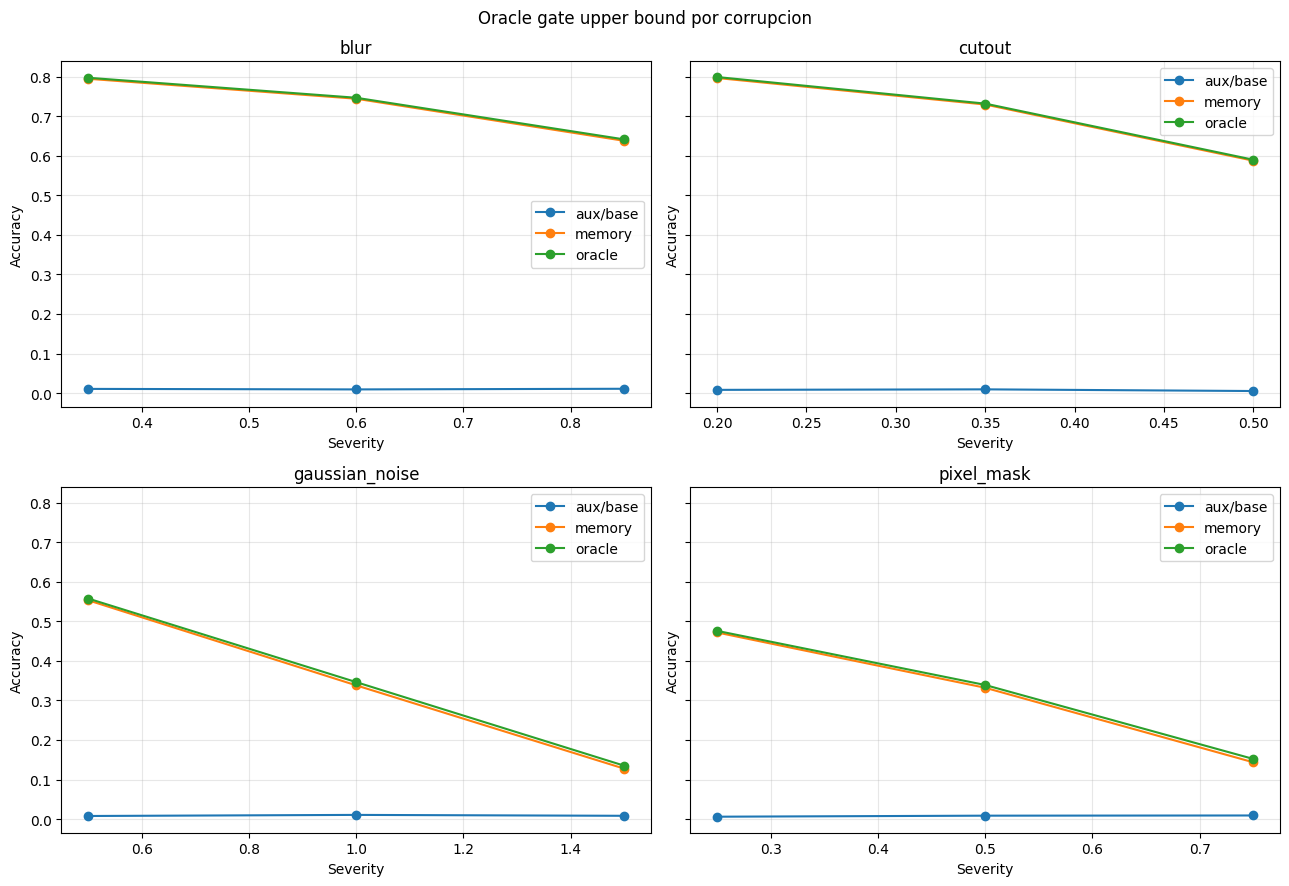

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
for ax, (corruption, sub) in zip(axes.flat, summary_by_condition.groupby('corruption', sort=True)):
    sub = sub.sort_values('severity')
    ax.plot(sub['severity'], sub['base_acc'], marker='o', label='aux/base')
    ax.plot(sub['severity'], sub['memory_acc'], marker='o', label='memory')
    ax.plot(sub['severity'], sub['oracle_acc'], marker='o', label='oracle')
    ax.set_title(corruption)
    ax.set_xlabel('Severity')
    ax.set_ylabel('Accuracy')
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle('Oracle gate upper bound por corrupcion')
plt.tight_layout()
fig.savefig(PLOTS / 'oracle_accuracy_by_condition.png', dpi=120, bbox_inches='tight')
plt.show()

## Efecto de memoria y senales del gate

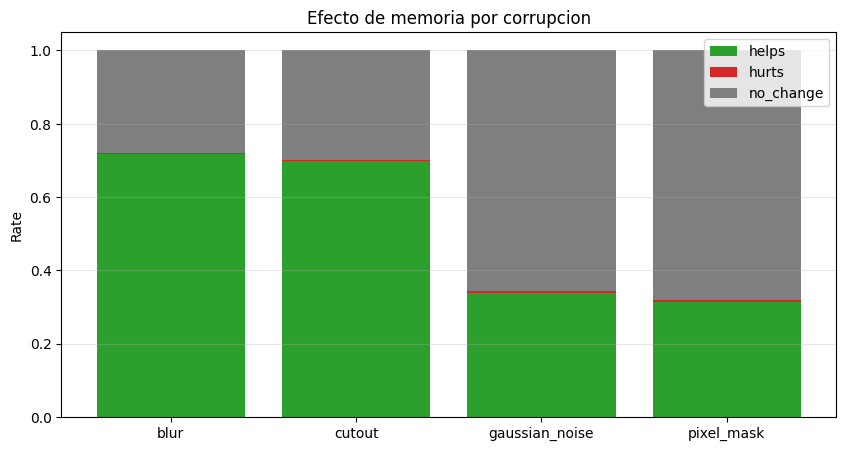

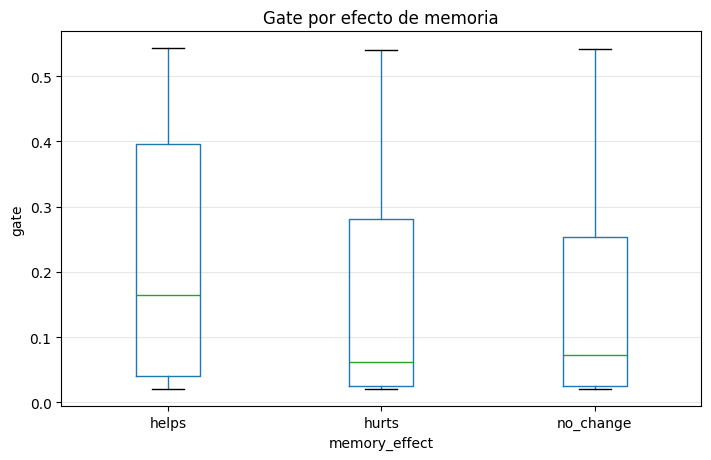

memory_effect,helps,hurts,no_change
corruption,,,
blur,0.718003,0.002873,0.279124
cutout,0.699192,0.002385,0.298423
gaussian_noise,0.337345,0.006668,0.655987
pixel_mask,0.314306,0.006505,0.679189


In [7]:
effect_by_corruption = (
    oracle_rows
    .groupby('corruption')['memory_effect']
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .reindex(columns=['helps', 'hurts', 'no_change'], fill_value=0.0)
)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(effect_by_corruption))
colors = {'helps': '#2ca02c', 'hurts': '#d62728', 'no_change': '#7f7f7f'}
for col in ['helps', 'hurts', 'no_change']:
    ax.bar(effect_by_corruption.index, effect_by_corruption[col], bottom=bottom, label=col, color=colors[col])
    bottom += effect_by_corruption[col].values
ax.set_ylabel('Rate')
ax.set_title('Efecto de memoria por corrupcion')
ax.grid(alpha=0.3, axis='y')
ax.legend()
fig.savefig(PLOTS / 'memory_effect_by_corruption.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
oracle_rows.boxplot(column='gate', by='memory_effect', ax=ax, grid=False)
ax.set_title('Gate por efecto de memoria')
ax.set_xlabel('memory_effect')
ax.set_ylabel('gate')
fig.suptitle('')
ax.grid(alpha=0.3, axis='y')
fig.savefig(PLOTS / 'gate_by_memory_effect.png', dpi=120, bbox_inches='tight')
plt.show()

effect_by_corruption

## Invariantes

In [8]:
tol = 1e-12
assert overall['oracle_acc'] + tol >= overall['memory_acc'], 'oracle_acc must be >= memory_acc'
assert overall['oracle_acc'] + tol >= overall['base_acc'], 'oracle_acc must be >= base_acc'

rate_sum = summary_by_condition[['helps_rate', 'hurts_rate', 'no_change_rate']].sum(axis=1)
assert np.allclose(rate_sum, 1.0), 'helps + hurts + no_change must equal 1 per condition'

expected_rows = oracle_rows.groupby(['corruption', 'severity']).size().nunique()
print('unique n per corrupt condition:', expected_rows)
print('all invariants passed')

unique n per corrupt condition: 1
all invariants passed
